# Objevování segmentů podle spotřeby dat účastníků pomocí PROC FASTCLUS


## Shrnutí pro vedení

Tým telekomunikační analytiky chce segmentovat svou základnu mobilních účastníků podle **měsíční spotřeby dat** bez použití libovolně zvolených GB prahů. Pomocí **PROC FASTCLUS** — vysoce výkonné procedury SAS pro shlukování metodou *k*-průměrů — necháme data, aby se sama rozdělila do latentních tříd spotřeby (nízká, střední a vysoká spotřeba dat). FASTCLUS najde střed každého segmentu, přiřadí každého účastníka k nejbližšímu z nich a uvede, jak čistě se segmenty oddělují — čímž promění jedinou spojitou metriku spotřeby v akční, daty řízenou segmentaci pro návrh tarifů a cílený marketing.


## Zdroje dat

Všechna data generuje inline první krok DATA — nejsou zde žádné externí soubory ani síťová volání. Účastníci jsou losováni ze tříkomponentní populace spotřeby, aby bylo možné zjištěné segmenty ověřit vůči známé referenční hodnotě.

| Datová sada | Řádků | Proměnná | Typ | Popis |
|---------|------|----------|------|-------------|
| `subscribers` | 1 500 | `id` | Num | Identifikátor účastníka (1–1500) |
| `subscribers` | 1 500 | `data_gb` | Num | Měsíční spotřeba mobilních dat v GB (metrika, na které shlukujeme) |
| `subscribers` | 1 500 | `segment_true` | Char | Latentní segment použitý k *vygenerování* hodnoty (Lehký ≈ N(3,1²) 50 %, Střední ≈ N(12,3²) 35 %, Náročný ≈ N(35,8²) 15 %); ponechán stranou pouze k ověření zjištěných segmentů — reálný analytik by jej neviděl |


# Objevování segmentů podle spotřeby dat účastníků

Mobilní operátoři jen zřídka mají čistý štítek, který říká *"toto je uživatel s vysokou spotřebou dat."* Co mají, je spojitá metrika — gigabajty spotřebované za měsíc — jejíž rozdělení je **vícevrcholové (multimodální)**: shluky uživatelů s nízkou, střední a vysokou spotřebou se překrývají na jediné ose. **Shluková analýza** zachází s tímto jediným sloupcem jako s geometrickým problémem: nalézá přirozená těžiště v rozdělení spotřeby a přiřazuje každého účastníka k nejbližšímu z nich, bez ručně zvolených prahů.

V tomto notebooku:

1. Vygenerujeme realistickou syntetickou základnu účastníků, jejíž spotřeba dat pochází ze tří skrytých segmentů.
2. Prozkoumáme okrajové rozdělení spotřeby a potvrdíme, že je vícevrcholové.
3. Standardizujeme metriku a spustíme **PROC FASTCLUS**, abychom rozdělili účastníky do tří segmentů spotřeby.
4. Popíšeme každý zjištěný segment na původní škále GB a poté ověříme jeho shodu se známou skutečností.

Štítek `segment_true` je vygenerován pouze proto, abychom mohli na konci ohodnotit kvalitu shlukování — v produkčním prostředí by neexistoval.


In [1]:
/* Vygenerování základny účastníků ze tří latentních segmentů spotřeby. */
/* Uživatelé s nízkou spotřebou převažují; malý ocas uživatelů s vysokou spotřebou generuje většinu tržeb. */
data subscribers;
   ŠTÍTEK id = "ID účastníka"
         data_gb = "Měsíční spotřeba dat (GB)"
         segment_true = "Skutečný segment";
   CALL streaminit(20260531);
   DÉLKA segment_true $16;
   OPAKUJ id = 1 TO 1500;
      u = rand('uniform');
      KDYŽ u < 0.50 PAK OPAKUJ;                 /* ~50 % uživatelů s nízkou spotřebou  */
         segment_true = 'Lehký';
         data_gb = rand('normal', 3.0, 1.0);
      KONEC;
      JINAK KDYŽ u < 0.85 PAK OPAKUJ;            /* ~35 % uživatelů se střední spotřebou */
         segment_true = 'Střední';
         data_gb = rand('normal', 12.0, 3.0);
      KONEC;
      JINAK OPAKUJ;                             /* ~15 % uživatelů s vysokou spotřebou  */
         segment_true = 'Náročný';
         data_gb = rand('normal', 35.0, 8.0);
      KONEC;
      KDYŽ data_gb < 0.1 PAK data_gb = 0.1; /* spotřeba nemůže být záporná */
      VÝSTUP;
   KONEC;
   PONECHAT id data_gb segment_true;
SPUSTIT;



NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


## První pohled na okrajové rozdělení

Před shlukováním shrneme jedinou vysvětlovanou proměnnou. Široký rozptyl a mezera mezi průměrem a hlavní hmotou uživatelů s nízkou spotřebou jsou typickým znakem podkladové směsi segmentů — jediná úroveň spotřeby by nedokázala reprodukovat jak hustý shluk s nízkou spotřebou, tak dlouhý ocas s vysokou spotřebou.


In [2]:
PROCEDURA PRŮMĚRY data=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   PROMĚNNÁ data_gb;
SPUSTIT;


                                                  The MEANS Procedure

 Variable  Label                                  N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Měsíční spotřeba dat (GB)            100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ------------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Histogram vizualizuje vícevrcholovost: vysoký hrot uživatelů s nízkou spotřebou poblíž 3 GB, hrb střední spotřeby poblíž 12 GB a řídký ocas vysoké spotřeby sahající přes 30 GB. Přesně tyto tři vrcholy jsou segmenty, které bude mít shlukování za úkol odhalit. Překryv jádrového odhadu hustoty sleduje stejný smíšený tvar.



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


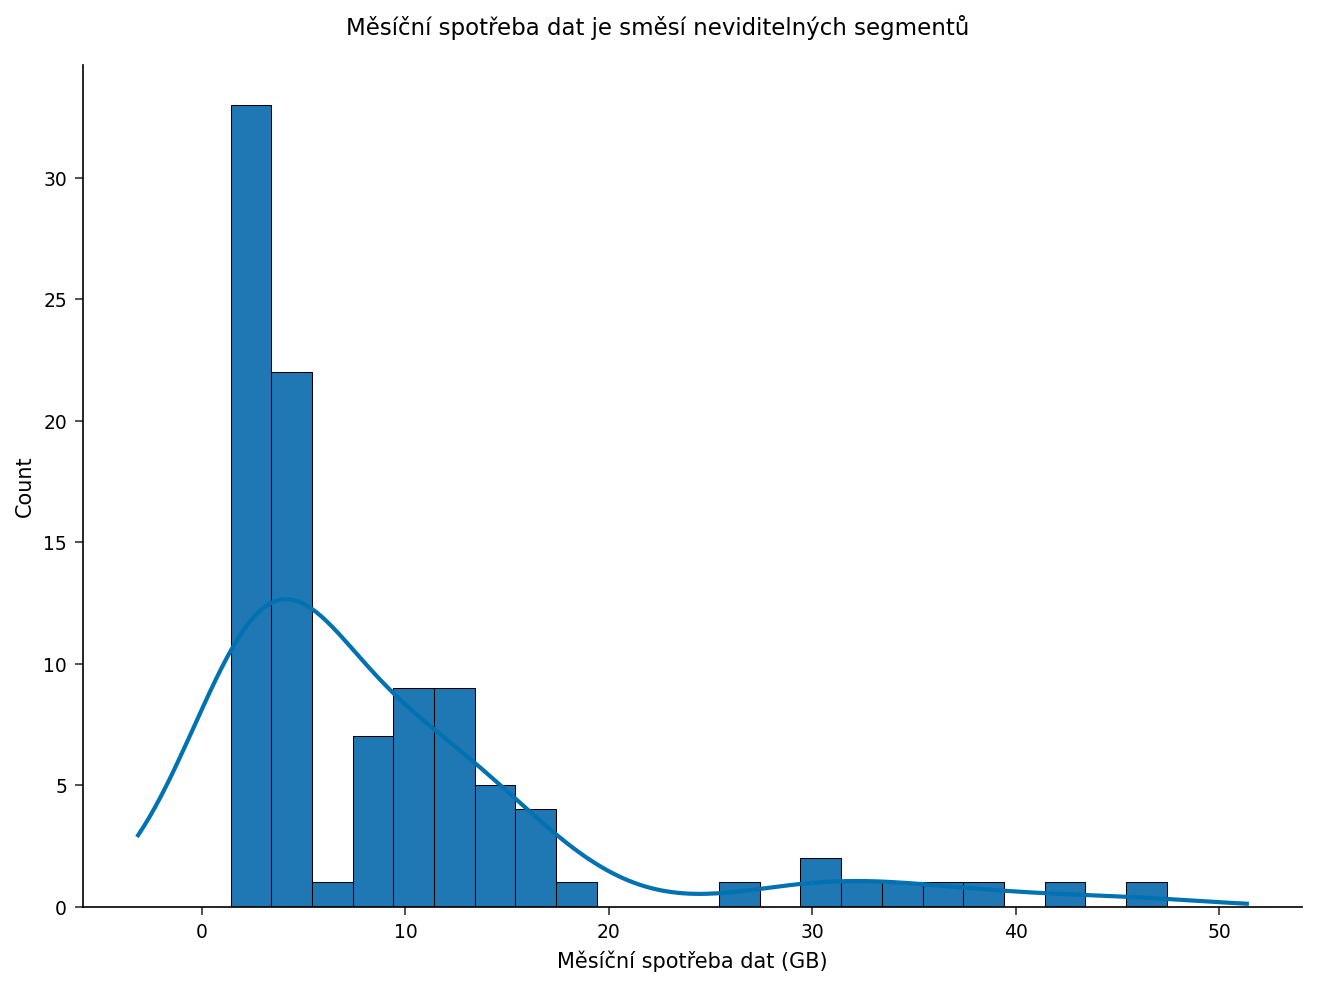

In [3]:
ODS GRAPHICS ON;
PROCEDURA SGPLOT data=subscribers;
   NÁZEV 'Měsíční spotřeba dat je směsí neviditelných segmentů';
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS ŠTÍTEK='Měsíční spotřeba dat (GB)';
SPUSTIT;
NÁZEV;
ODS GRAPHICS OFF;


## Převedení spotřeby na společné měřítko

*k*-průměry rozdělují body podle euklidovské vzdálenosti, takže výsledek řídí původní měřítko proměnné. U jediné metriky to jen posune osu, ale standardizace na průměr 0 / směrodatnou odchylku 1 pomocí **PROC STANDARD** je zvyk, který udrží postup správný ve chvíli, kdy přibude druhá metrika spotřeby (hlasové minuty, dny v roamingu). Shlukujeme na standardizovaném sloupci a výsledky uvádíme zpět v původním měřítku GB.


In [4]:
PROCEDURA STANDARD data=subscribers out=subs_std mean=0 std=1;
   PROMĚNNÁ data_gb;
SPUSTIT;



NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Rozdělení účastníků do tří segmentů spotřeby

Vedeni doménovou znalostí úrovní nízká / střední / vysoká spotřeba, požádáme **PROC FASTCLUS** o `MAXCLUSTERS=3`. Procedura založí tři středy, přiřadí každého účastníka k nejbližšímu z nich, přepočítá středy a opakuje, dokud se přiřazení přestanou měnit (`CONVERGE=` s limitem `MAXITER=`). `SEED=` zajišťuje reprodukovatelnou inicializaci. Datová sada `OUT=` nese pro každého účastníka štítek `CLUSTER` a jeho `DISTANCE` k přiřazenému středu; `MEAN=` zapisuje centroidy segmentů.

Čtěte diagnostiku procedury z hlediska kvality oddělení: vysoké **R-Squared** (podíl celkového rozptylu spotřeby vysvětlený segmenty) i velké **Pseudo F** ukazují na dobře oddělené, kompaktní segmenty.


In [5]:
PROCEDURA FASTCLUS data=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   PROMĚNNÁ data_gb;
   NÁZEV 'Tři segmenty spotřeby pomocí k-means';
SPUSTIT;
NÁZEV;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Popis zjištěných segmentů

Štítky shluků jsou operativní až ve chvíli, kdy popíšeme každý segment obchodními pojmy. Sloučíme přiřazení zpět na původní (nestandardizovanou) spotřebu a shrneme velikost a typickou spotřebu každého segmentu na škále GB — čísla, podle kterých tým pro návrh tarifů nebo marketing skutečně jedná.


In [6]:
data memberships;
   ŠTÍTEK CLUSTER = "Shluk"
         distance = "Vzdálenost od středu";
   SLOUČIT subscribers
         clusters(PONECHAT=id CLUSTER distance);
   PODLE id;
SPUSTIT;

PROCEDURA PRŮMĚRY data=memberships n mean MIN MAX maxdec=2;
   TŘÍDA CLUSTER;
   PROMĚNNÁ data_gb distance;
SPUSTIT;

PROCEDURA TISK data=memberships(obs=10) noobs ŠTÍTEK;
   PROMĚNNÁ id data_gb CLUSTER distance segment_true;
SPUSTIT;


                                                  The MEANS Procedure

                               Analysis Variable : data_gb Měsíční spotřeba dat (GB)

        Shluk             N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                  Analysis Variable : DISTANCE Vzdálenost od středu

        Shluk             N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09   


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Ověření zjištěných segmentů

Protože se jedná o syntetická data, ponechali jsme stranou `segment_true`, štítek použitý ke generování hodnoty každého účastníka. Křížová tabulace modelem zjištěného `CLUSTER` proti skutečnému segmentu ukazuje, jak čistě se populace rozdělila. Silná koncentrace podél jediného zobrazení shluk-segment znamená dobré zotavení; mimodiagonální hmota se soustředí tam, kde se hranice nízká/střední nebo střední/vysoká spotřeba překrývají.


In [7]:
PROCEDURA ČETNOSTI data=memberships;
   TABLES CLUSTER * segment_true / norow nocol nopercent;
SPUSTIT;


                                                   The FREQ Procedure

Table of Shluk by Skutečný segment

Shluk |     Lehký |   Náročný |   Střední |      Total
------+-----------+-----------+-----------+-----------
1     |        54 |         0 |         3 |         57
------+-----------+-----------+-----------+-----------
2     |         0 |         9 |         0 |          9
------+-----------+-----------+-----------+-----------
3     |         0 |         1 |        33 |         34
------+-----------+-----------+-----------+-----------
Total |        54 |        10 |        36 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interpretace výsledků

- **Středy segmentů.** Tři shluky dopadají téměř přesně na naplánované úrovně spotřeby — uživatelé s nízkou spotřebou poblíž **3 GB**, se střední spotřebou poblíž **13 GB** a s vysokou spotřebou poblíž **37 GB** — což kvantifikuje jak *kde* každý segment leží, tak *jak velký* je. Malý segment vysoké spotřeby, přestože tvoří jen zlomek účastníků, nese neúměrně velký podíl na celkově přenesených datech — klasický hnací faktor rozhodování o kapacitě sítě a prémiových tarifech.
- **Kvalita oddělení.** PROC FASTCLUS uvádí vysoké celkové **R-Squared** a velké **Pseudo F**, což potvrzuje, že tři segmenty jsou kompaktní a dobře oddělené, nikoli artefakty libovolně zvoleného řezu. Jediná úroveň by ponechala většinu tohoto rozptylu spotřeby nevysvětlenou.
- **Žádné ručně zvolené prahy.** Segmentace vychází ze samotné geometrie rozdělení spotřeby. Procedura zvolila hranice; my jsme zvolili pouze *kolik* úrovní požadovat, vedeni zjevným třívrcholovým tvarem histogramu.
- **Akční výstup.** Datová sada `OUT=` dává každému účastníkovi štítek segmentu *a* `DISTANCE` k jeho středu. Účastníci daleko od jakéhokoli středu — nebo ležící mezi hranicí nízké/střední spotřeby — jsou přesně ti zákazníci, u kterých se vyplatí A/B testování nabídek navýšení tarifu, zatímco těsně shluknutí uživatelé s vysokou spotřebou jsou vysoce důvěryhodní kandidáti na tarify s ohledem na kapacitu nebo neomezené tarify.

Stručně, PROC FASTCLUS převádí jedinou spojitou metriku spotřeby na daty řízenou segmentaci — bez potřeby ručně volených GB prahů.
